# COMEX EFP Expansion
## COMEX Futures Curve & EFP Basis Carry Strategies

**Research question:** Does the COMEX futures curve for gold (GC) and silver (SI) contain
mean-reverting signals that are distinct from the LBMA lease curve, and can those signals
be traded systematically via calendar spreads and EFP basis?

**Standalone expansion of** `silver_gold_lease_curve_v2.ipynb` — same data file, same
backtest engine, same blotter format (Section 10).

Sections:
- 0: Config
- 1: Data Load & Validation
- 2: Feature Construction (Blocks A–D, 12 features)
- 3: Z-Score Signals
- 4: Parameter Sweep & Backtest (936 runs)
- 5: COMEX Portfolio Construction
- 6: Combined LBMA + COMEX Portfolio
- 7: Attribution & Regime Analysis
- 8: Daily Signal Integration (blotter-compatible)
- 9: Bloomberg Data Pull Spec


# 0. Config

In [1]:
import os, itertools, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
warnings.filterwarnings('ignore')

CONFIG = {
    # Data
    'DATA_FILE':          'data/data.csv',
    'START_DATE':         '2018-01-01',
    'END_DATE':           '2026-02-22',
    'IS_CUTOFF':          '2023-01-01',

    # COMEX tenor approximations (days between contracts)
    # GC: bi-monthly delivery (Feb/Apr/Jun/Aug/Oct/Dec)
    # SI: Mar/May/Jul/Sep/Dec — variable gap, use 61d as conservative base
    'GC_CALENDAR_DAYS':   {'1_2': 61, '2_3': 61, '1_3': 122},
    'SI_CALENDAR_DAYS':   {'1_2': 61, '2_3': 61},

    # EFP tenor approximation: front contract ~30 days to expiry
    'EFP_DAYS':           30,

    # Roll contamination filter
    'EFP_CLIP_BP':        800,   # annualised bp; beyond this = artefact

    # Signal construction
    'ROLLING_WINDOW':     252,
    'MIN_PERIODS':        126,
    'CAL_ROLLING_WINDOW': 504,   # longer for persistent calendar spreads
    'CAL_MIN_PERIODS':    252,

    # Backtest parameters (same grid as LBMA notebook)
    'ENTRY_Z_GRID':  [1.5, 2.0, 2.5],
    'EXIT_Z_GRID':   [0.3, 0.5, 0.75],
    'STOP_Z':        3.5,
    'MAX_HOLD_GRID': [20, 63, 126, 252],
    'COST_BP_GRID':  [0.08, 0.12],

    # Portfolio construction
    'MIN_OOS_SHARPE':   1.5,
    'MIN_OOS_TRADES':   8,
    'MIN_IS_TRADES':    3,
    'CORR_THRESHOLD':   0.60,
    'MAX_DD_BLOWUP':    3.0,

    # Position sizing (same as LBMA notebook)
    'TARGET_VOL_BP':   1.0,
    'MAX_NOTIONAL':    5.0,
    'MIN_NOTIONAL':    0.1,

    # Output
    'SAVE_OUTPUTS': True,
    'OUTPUT_DIR':   'outputs_comex/',
}

os.makedirs(CONFIG['OUTPUT_DIR'], exist_ok=True)

# Unpack CONFIG into module-level names (matches LBMA notebook style)
ROLLING_WINDOW     = CONFIG['ROLLING_WINDOW']
MIN_PERIODS        = CONFIG['MIN_PERIODS']
CAL_ROLLING_WINDOW = CONFIG['CAL_ROLLING_WINDOW']
CAL_MIN_PERIODS    = CONFIG['CAL_MIN_PERIODS']
STOP_Z             = CONFIG['STOP_Z']
TARGET_VOL_BP      = CONFIG['TARGET_VOL_BP']
MAX_NOTIONAL       = CONFIG['MAX_NOTIONAL']
MIN_NOTIONAL       = CONFIG['MIN_NOTIONAL']
MIN_OOS_SHARPE     = CONFIG['MIN_OOS_SHARPE']
MIN_OOS_TRADES     = CONFIG['MIN_OOS_TRADES']
MIN_IS_TRADES      = CONFIG['MIN_IS_TRADES']
CORR_THRESHOLD     = CONFIG['CORR_THRESHOLD']
MAX_DD_BLOWUP      = CONFIG['MAX_DD_BLOWUP']
SAVE_OUTPUTS       = CONFIG['SAVE_OUTPUTS']
OUTPUT_DIR         = CONFIG['OUTPUT_DIR']
ENTRY_Z_GRID       = CONFIG['ENTRY_Z_GRID']
EXIT_Z_GRID        = CONFIG['EXIT_Z_GRID']
MAX_HOLD_GRID      = CONFIG['MAX_HOLD_GRID']
COST_BP_GRID       = CONFIG['COST_BP_GRID']
IS_START           = CONFIG['START_DATE']
IS_END             = CONFIG['IS_CUTOFF']
OOS_START          = CONFIG['IS_CUTOFF']
OOS_END            = CONFIG['END_DATE']

# Regime thresholds (same as LBMA notebook)
REGIME_ZIRP_MAX  = 0.50
REGIME_HIGH_MIN  = 3.50
FUNDING_COL      = 'sofr_ois_3m'

# Volatility regime (same as LBMA)
VOL_WINDOW          = 20
HIGH_VOL_PCTILE     = 75
LOW_VOL_PCTILE      = 25
FUNDING_SHOCK_WINDOW = 5
FUNDING_SHOCK_MULT  = 1.5

REBAL_FREQ         = 'MS'
RISK_PARITY_WINDOW = 63

print("Config loaded.")
print(f"  IS:  {IS_START} → {IS_END}")
print(f"  OOS: {OOS_START} → {OOS_END}")
print(f"  Grid: {len(ENTRY_Z_GRID)}×{len(EXIT_Z_GRID)}×{len(MAX_HOLD_GRID)}×{len(COST_BP_GRID)}"
      f" = {len(ENTRY_Z_GRID)*len(EXIT_Z_GRID)*len(MAX_HOLD_GRID)*len(COST_BP_GRID)} param combos")


Config loaded.
  IS:  2018-01-01 → 2023-01-01
  OOS: 2023-01-01 → 2026-02-22
  Grid: 3×3×4×2 = 72 param combos


# 1. Data Load & Validation

In [2]:
print('Section 1: Loading data...')

df = pd.read_csv(CONFIG['DATA_FILE'])
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').drop_duplicates('date').set_index('date')
df = df.ffill(limit=3)

REQUIRED_COLS = [
    'gc_fut_front', 'gc_fut_second', 'gc_fut_third',
    'si_fut_front', 'si_fut_second', 'si_fut_third',
    'xauusd_spot', 'xagusd_spot', 'lbma_gold_am',
    'sofr_ois_1m', 'sofr_ois_3m', 'sofr_ois_6m',
    'xau_swap_1m', 'xau_swap_3m', 'xag_swap_1m', 'xag_swap_3m',
]

missing_cols = [c for c in REQUIRED_COLS if c not in df.columns]
if missing_cols:
    raise ValueError(f"ABORT: required columns missing: {missing_cols}")

print(f"Rows: {len(df)}  |  {df.index[0].date()} → {df.index[-1].date()}")
print(f"Columns: {df.shape[1]}")
print()

print("Missing value % (required columns):")
for c in REQUIRED_COLS:
    pct = df[c].isna().mean() * 100
    flag = '  *** HIGH' if pct > 5 else ''
    print(f"  {c:<25}: {pct:.1f}%{flag}")
print()

# Price sanity check
ok = df['gc_fut_front'].dropna()
spot_ok = df['xauusd_spot'].dropna()
common = ok.index.intersection(spot_ok.index)
ratio = (ok.loc[common] / spot_ok.loc[common])
below_095 = (ratio < 0.95).sum()
print(f"Sanity check — GC front < 0.95×spot: {below_095} days "
      f"({'FAIL' if below_095 > 0 else 'OK'})")

# Contango check: GC2 > GC1 on >80% of days
both = df[['gc_fut_front','gc_fut_second']].dropna()
contango_pct = (both['gc_fut_second'] > both['gc_fut_front']).mean() * 100
flag = '' if contango_pct >= 80 else '  *** WARN: expected >80%'
print(f"Contango (GC2 > GC1) on {contango_pct:.1f}% of days{flag}")

# Rate regime
df['rate_regime'] = np.where(
    df[FUNDING_COL] < REGIME_ZIRP_MAX, 'zirp',
    np.where(df[FUNDING_COL] >= REGIME_HIGH_MIN, 'high', 'mid'))

print()
print("Rate regime distribution:")
rc = df['rate_regime'].value_counts()
for r in ['zirp', 'mid', 'high']:
    n = rc.get(r, 0)
    print(f"  {r:<6}: {n:>5d} days ({n/len(df)*100:.1f}%)")


Section 1: Loading data...
Rows: 2971  |  2018-01-01 → 2026-02-22
Columns: 94

Missing value % (required columns):
  gc_fut_front             : 0.0%
  gc_fut_second            : 0.0%
  gc_fut_third             : 0.0%
  si_fut_front             : 0.0%
  si_fut_second            : 0.0%
  si_fut_third             : 0.0%
  xauusd_spot              : 0.0%
  xagusd_spot              : 0.0%
  lbma_gold_am             : 0.0%
  sofr_ois_1m              : 0.0%
  sofr_ois_3m              : 0.0%
  sofr_ois_6m              : 0.0%
  xau_swap_1m              : 0.0%
  xau_swap_3m              : 0.0%
  xag_swap_1m              : 0.0%
  xag_swap_3m              : 0.0%

Sanity check — GC front < 0.95×spot: 0 days (OK)
Contango (GC2 > GC1) on 99.6% of days

Rate regime distribution:
  zirp  :   746 days (25.1%)
  mid   :   979 days (33.0%)
  high  :  1246 days (41.9%)


# 2. Feature Construction (Blocks A–D)

- **Block A** — COMEX Calendar Spread Carry (annualised, same units as LBMA lease rates)
- **Block B** — COMEX vs LBMA Cross-Venue Basis (core pricing efficiency signal)
- **Block C** — EFP Basis (COMEX front vs LBMA spot; roll-filter applied)
- **Block D** — COMEX Curve Slope vs LBMA Slope (relative shape signal)


In [3]:
print('Section 2: Building COMEX features...')

GC_DAYS_12 = CONFIG['GC_CALENDAR_DAYS']['1_2']   # 61
GC_DAYS_23 = CONFIG['GC_CALENDAR_DAYS']['2_3']   # 61
GC_DAYS_13 = CONFIG['GC_CALENDAR_DAYS']['1_3']   # 122
SI_DAYS_12 = CONFIG['SI_CALENDAR_DAYS']['1_2']   # 61
EFP_DAYS   = CONFIG['EFP_DAYS']                   # 30
EFP_CLIP   = CONFIG['EFP_CLIP_BP']                # 800

# ── BLOCK A: COMEX Calendar Spread Carry ──────────────────────────────────
# Annualised carry rate — same units as LBMA lease rates (%)
# Formula: (GC2 - GC1) / GC1 × (360/days) × 100
df['gc_comex_carry_2m'] = (
    (df['gc_fut_second'] - df['gc_fut_front']) /
     df['gc_fut_front'] * (360 / GC_DAYS_12) * 100
)
df['gc_comex_carry_4m'] = (
    (df['gc_fut_third'] - df['gc_fut_front']) /
     df['gc_fut_front'] * (360 / GC_DAYS_13) * 100
)
df['si_comex_carry_2m'] = (
    (df['si_fut_second'] - df['si_fut_front']) /
     df['si_fut_front'] * (360 / SI_DAYS_12) * 100
)
# Calendar spread curvature: how carry accelerates across the curve
df['gc_cal_curvature'] = df['gc_comex_carry_4m'] - df['gc_comex_carry_2m']

# GC/SI calendar spread ratio: mean-reverts around 1.0
df['gc_si_cal_ratio'] = (
    df['gc_comex_carry_2m'] / df['si_comex_carry_2m']
).replace([np.inf, -np.inf], np.nan)

# ── BLOCK B: COMEX vs LBMA Cross-Venue Basis ─────────────────────────────
# Parity: COMEX calendar carry ≈ OIS - lease rate
# Deviation = cross-venue pricing inefficiency → tradeable convergence
df['xau_lease_1m'] = df['sofr_ois_1m'] - df['xau_swap_1m']
df['xau_lease_3m'] = df['sofr_ois_3m'] - df['xau_swap_3m']
df['xau_lease_2m'] = (df['xau_lease_1m'] + df['xau_lease_3m']) / 2
df['xag_lease_1m'] = df['sofr_ois_1m'] - df['xag_swap_1m']
df['xag_lease_3m'] = df['sofr_ois_3m'] - df['xag_swap_3m']
df['xag_lease_2m'] = (df['xag_lease_1m'] + df['xag_lease_3m']) / 2
df['ois_2m']       = (df['sofr_ois_1m'] + df['sofr_ois_3m']) / 2

df['xau_lbma_carry_2m'] = df['ois_2m'] - df['xau_lease_2m']
df['xag_lbma_carry_2m'] = df['ois_2m'] - df['xag_lease_2m']

# COMEX vs LBMA basis: positive = COMEX carry is rich vs LBMA
df['gc_comex_lbma_basis']   = df['gc_comex_carry_2m'] - df['xau_lbma_carry_2m']
df['si_comex_lbma_basis']   = df['si_comex_carry_2m'] - df['xag_lbma_carry_2m']
df['gc_si_comex_basis_spread'] = df['gc_comex_lbma_basis'] - df['si_comex_lbma_basis']

# ── BLOCK C: EFP Basis ────────────────────────────────────────────────────
# EFP dislocation = actual (futures-spot) minus theoretical carry
df['efp_xau_actual']  = df['gc_fut_front'] - df['xauusd_spot']
df['efp_xag_actual']  = df['si_fut_front'] - df['xagusd_spot']
df['efp_xau_theo']    = df['xauusd_spot'] * df['xau_swap_1m'] / 100 * (EFP_DAYS / 360)
df['efp_xag_theo']    = df['xagusd_spot'] * df['xag_swap_1m'] / 100 * (EFP_DAYS / 360)
df['efp_xau_dislocn'] = df['efp_xau_actual'] - df['efp_xau_theo']
df['efp_xag_dislocn'] = df['efp_xag_actual'] - df['efp_xag_theo']

# Annualised and normalised to bp (same units as LBMA features)
df['efp_xau_bp'] = df['efp_xau_dislocn'] / df['xauusd_spot'] * 10000 * (360 / EFP_DAYS)
df['efp_xag_bp'] = df['efp_xag_dislocn'] / df['xagusd_spot'] * 10000 * (360 / EFP_DAYS)

# ROLL DATE FILTER — critical: clip roll artefacts + adjacent days
df.loc[df['efp_xau_bp'].abs() > EFP_CLIP, 'efp_xau_bp'] = np.nan
efp_nan_idx = df['efp_xau_bp'].isna()
df.loc[efp_nan_idx.shift(1).fillna(False), 'efp_xau_bp'] = np.nan
df.loc[efp_nan_idx.shift(-1).fillna(False), 'efp_xau_bp'] = np.nan

df.loc[df['efp_xag_bp'].abs() > EFP_CLIP, 'efp_xag_bp'] = np.nan
efp_nan_idx_ag = df['efp_xag_bp'].isna()
df.loc[efp_nan_idx_ag.shift(1).fillna(False), 'efp_xag_bp'] = np.nan
df.loc[efp_nan_idx_ag.shift(-1).fillna(False), 'efp_xag_bp'] = np.nan

# Cross-metal EFP difference
df['efp_xau_xag_diff'] = df['efp_xau_bp'] - df['efp_xag_bp']

# ── BLOCK D: COMEX Curve Slope vs LBMA Slope ─────────────────────────────
df['gc_comex_curve_slope']  = (df['gc_comex_carry_4m'] - df['gc_comex_carry_2m']) / 2.0
df['xau_lbma_slope_1m_3m']  = df['xau_lease_1m'] - df['xau_lease_3m']
df['comex_lbma_slope_basis'] = df['gc_comex_curve_slope'] - df['xau_lbma_slope_1m_3m']

# ── Feature list ──────────────────────────────────────────────────────────
# Block A (calendar, use CAL_ROLLING_WINDOW)
cal_features = [
    'gc_comex_carry_2m', 'gc_comex_carry_4m', 'si_comex_carry_2m',
    'gc_cal_curvature', 'gc_si_cal_ratio',
]
# Block B (basis, use ROLLING_WINDOW)
basis_features = [
    'gc_comex_lbma_basis', 'si_comex_lbma_basis', 'gc_si_comex_basis_spread',
]
# Block C (EFP, use ROLLING_WINDOW — less persistent after cleaning)
efp_features = [
    'efp_xau_bp', 'efp_xag_bp', 'efp_xau_xag_diff',
]
# Block D (slope basis, use CAL_ROLLING_WINDOW — persistent)
slope_features = [
    'gc_comex_curve_slope', 'comex_lbma_slope_basis',
]

comex_features = cal_features + basis_features + efp_features + slope_features
print(f"Total features: {len(comex_features)}")

# Feature quality report
print()
print(f"{'Feature':<30}  {'n':>5}  {'mean':>8}  {'std':>8}  {'nan%':>6}")
print('-' * 65)
for c in comex_features:
    s = df[c].dropna()
    pct_nan = df[c].isna().mean() * 100
    print(f"  {c:<28}  {len(s):>5d}  {s.mean():>8.3f}  {s.std():>8.3f}  {pct_nan:>5.1f}%")

if SAVE_OUTPUTS:
    df[comex_features].reset_index().to_csv(f'{OUTPUT_DIR}01_comex_features.csv', index=False)
    print(f"\nSaved: {OUTPUT_DIR}01_comex_features.csv")


Section 2: Building COMEX features...
Total features: 13

Feature                             n      mean       std    nan%
-----------------------------------------------------------------
  gc_comex_carry_2m              2970     3.455     1.783    0.0%
  gc_comex_carry_4m              2970     3.412     1.757    0.0%
  si_comex_carry_2m              2970     4.303     2.250    0.0%
  gc_cal_curvature               2970    -0.043     0.288    0.0%
  gc_si_cal_ratio                2970     0.843     0.559    0.0%
  gc_comex_lbma_basis            2970     0.696     0.873    0.0%
  si_comex_lbma_basis            2970     2.135     2.470    0.0%
  gc_si_comex_basis_spread       2970    -1.439     2.424    0.0%
  efp_xau_bp                     2484   -40.482   299.331   16.4%
  efp_xag_bp                     1706   -23.447   375.375   42.6%
  efp_xau_xag_diff               1602   -30.503   403.251   46.1%
  gc_comex_curve_slope           2970    -0.021     0.144    0.0%
  comex_lbma_slope

# 3. Z-Score Signals

Calendar spread features (Blocks A, D): use 504-day lookback (ACF lag20 > 0.75 — highly persistent).
EFP & basis features (Blocks B, C): use 252-day lookback (less persistent post roll-filter).


In [4]:
print('Section 3: Constructing z-score signals...')

new_cols = {}
signal_cols = []

# Determine per-feature rolling window
cal_set = set(cal_features + slope_features)

for col in comex_features:
    use_long = col in cal_set
    rw  = CAL_ROLLING_WINDOW if use_long else ROLLING_WINDOW
    mp  = CAL_MIN_PERIODS    if use_long else MIN_PERIODS

    roll = df[col].rolling(rw, min_periods=mp)
    rv   = df[col].rolling(VOL_WINDOW).std()
    rv_rl = rv.rolling(rw, min_periods=mp)

    new_cols[f'z_{col}']       = (df[col] - roll.mean()) / roll.std()
    new_cols[f'z_fast_{col}']  = (
        (df[col] - df[col].rolling(126, min_periods=63).mean())
        / df[col].rolling(126, min_periods=63).std()
    )
    new_cols[f'rv_{col}']      = rv
    new_cols[f'pctile_{col}']  = df[col].rolling(rw, min_periods=mp).rank(pct=True) * 100
    new_cols[f'highvol_{col}'] = (rv > rv_rl.quantile(HIGH_VOL_PCTILE/100)).fillna(False)
    new_cols[f'lowvol_{col}']  = (rv < rv_rl.quantile(LOW_VOL_PCTILE/100)).fillna(False)
    signal_cols.append(f'z_{col}')

# Funding shock (shared with LBMA notebook logic)
fund_chg = df[FUNDING_COL].diff(FUNDING_SHOCK_WINDOW)
fund_std  = fund_chg.rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).std()
new_cols['funding_shock'] = (fund_chg.abs() > FUNDING_SHOCK_MULT * fund_std).fillna(False)

# Curve inversion proxy from OIS (simple 3m-1m slope)
ois_slope = df['sofr_ois_3m'] - df['sofr_ois_1m']
new_cols['curve_inverted'] = ois_slope < -0.10
new_cols['gold_vol_high']  = df['gold_vol_index'] > 25.0 if 'gold_vol_index' in df.columns                              else pd.Series(False, index=df.index)

df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1).copy()

# Verification: IS mean/std of z-scores
df_is = df.loc[IS_START:IS_END]
print(f"\nZ-score quality check (IS period {IS_START}→{IS_END}):")
print(f"  {'Signal':<35}  {'IS mean':>8}  {'IS std':>8}  {'|z|>8 days':>10}")
print('  ' + '-'*70)
ok_count = 0
for zcol in signal_cols:
    if zcol not in df_is.columns: continue
    s = df_is[zcol].dropna()
    extreme = (s.abs() > 8).sum()
    flag = '  *** DATA ERROR' if extreme > 0 else ''
    print(f"  {zcol:<35}  {s.mean():>8.3f}  {s.std():>8.3f}  {extreme:>10}{flag}")
    ok_count += 1

print(f"\n{ok_count} z-scores constructed.")

if SAVE_OUTPUTS:
    sig_df = df[signal_cols + ['rate_regime']].reset_index()
    sig_df.to_csv(f'{OUTPUT_DIR}02_comex_signals.csv', index=False)
    print(f"Saved: {OUTPUT_DIR}02_comex_signals.csv")


Section 3: Constructing z-score signals...

Z-score quality check (IS period 2018-01-01→2023-01-01):
  Signal                                IS mean    IS std  |z|>8 days
  ----------------------------------------------------------------------
  z_gc_comex_carry_2m                     0.209     1.683           3  *** DATA ERROR
  z_gc_comex_carry_4m                     0.068     1.745           0
  z_si_comex_carry_2m                     0.194     1.531           0
  z_gc_cal_curvature                      0.005     1.471           5  *** DATA ERROR
  z_gc_si_cal_ratio                      -0.015     1.346           9  *** DATA ERROR
  z_gc_comex_lbma_basis                   0.053     1.432           3  *** DATA ERROR
  z_si_comex_lbma_basis                   0.212     1.413           0
  z_gc_si_comex_basis_spread             -0.085     1.380           2  *** DATA ERROR
  z_efp_xau_bp                            0.012     1.016           0
  z_efp_xag_bp                           -0.06

## 3b. Z-Score Time Series (roll-filter validation)

Section 3b: Z-score plots...


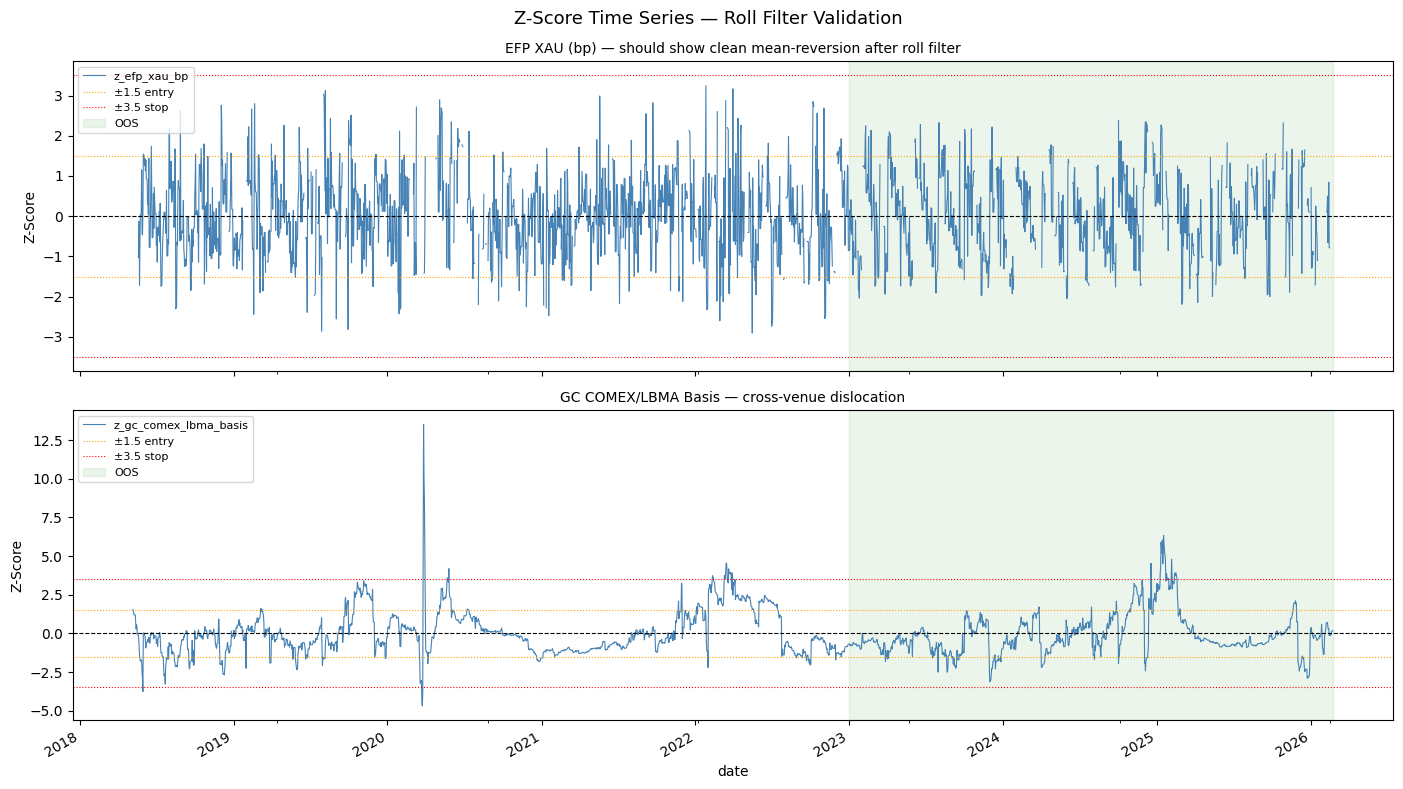

Z-score plots complete.


In [5]:
print('Section 3b: Z-score plots...')

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Z-Score Time Series — Roll Filter Validation', fontsize=13)

for ax, zcol, title in [
    (axes[0], 'z_efp_xau_bp',        'EFP XAU (bp) — should show clean mean-reversion after roll filter'),
    (axes[1], 'z_gc_comex_lbma_basis','GC COMEX/LBMA Basis — cross-venue dislocation'),
]:
    if zcol in df.columns:
        df[zcol].plot(ax=ax, lw=0.8, color='steelblue', label=zcol)
        ax.axhline(0,   color='black', lw=0.8, ls='--')
        ax.axhline(1.5, color='orange', lw=0.8, ls=':', label='±1.5 entry')
        ax.axhline(-1.5,color='orange', lw=0.8, ls=':')
        ax.axhline(3.5, color='red',    lw=0.8, ls=':', label='±3.5 stop')
        ax.axhline(-3.5,color='red',    lw=0.8, ls=':')
        ax.axvspan(pd.Timestamp(OOS_START), df.index[-1],
                   alpha=0.08, color='green', label='OOS')
        ax.set_title(title, fontsize=10)
        ax.legend(fontsize=8, loc='upper left')
        ax.set_ylabel('Z-Score')
    else:
        ax.text(0.5, 0.5, f'{zcol} not found', transform=ax.transAxes, ha='center')

plt.tight_layout()
if SAVE_OUTPUTS:
    plt.savefig(f'{OUTPUT_DIR}03_zscore_validation.png', dpi=120, bbox_inches='tight')
plt.show()
print("Z-score plots complete.")


# 4. Parameter Sweep & Backtest

`backtest_single()` copied verbatim from `silver_gold_lease_curve_v2.ipynb`.

In [6]:
print('Section 4: Defining backtest engine (verbatim copy from LBMA notebook)...')

def backtest_single(df, signal_col, feature_col,
                    entry_z=2.0, exit_z=0.5,
                    stop_z=3.5, max_hold=63,
                    cost_bp=0.04,
                    use_fast_z=False,
                    curve_inversion_filter=False,
                    curve_monotone_filter=False,
                    gold_vol_boost=False,
                    mono_gate=False,
                    non_mono_dates=None):
    """
    State machine backtest for one feature / signal pair.
    Copied verbatim from silver_gold_lease_curve_v2.ipynb.
    mono_gate disabled by default for COMEX (no OIS monotonicity issue).
    """
    z    = df[signal_col].values
    feat = df[feature_col].values
    rv   = df[f'rv_{feature_col}'].values
    fs   = df['funding_shock'].values
    hv   = df[f'highvol_{feature_col}'].values
    lv   = df[f'lowvol_{feature_col}'].values
    gvh  = df['gold_vol_high'].values
    ci   = df['curve_inverted'].values

    z_fast_col = f'z_fast_{feature_col}'
    z_fast = df[z_fast_col].values if z_fast_col in df.columns else None
    rate_regime_arr = df['rate_regime'].values if 'rate_regime' in df.columns else None
    cm = (df['curve_monotone'].values
          if (curve_monotone_filter and 'curve_monotone' in df.columns) else None)

    dates = df.index
    _non_mono = non_mono_dates if non_mono_dates is not None else set()

    pos   = np.zeros(len(df))
    pnl   = np.zeros(len(df))
    carry = np.zeros(len(df))
    state = 0; days_held = 0; notional = 0.0
    entry_i = None; entry_z_ = None; entry_f_ = None
    trades = []

    for i in range(1, len(df)):
        if np.isnan(z[i]):
            continue

        df_feat = feat[i] - feat[i-1]
        eff_entry_z = (entry_z * 0.75
                       if (gold_vol_boost and not np.isnan(gvh[i]) and gvh[i])
                       else entry_z)

        if state == 0:
            enter = (abs(z[i]) >= eff_entry_z
                     and not fs[i]
                     and not (curve_inversion_filter and ci[i])
                     and not (curve_monotone_filter and cm is not None and not cm[i])
                     and not (mono_gate and dates[i] in _non_mono))
            use_fast_here = (
                use_fast_z or
                (rate_regime_arr is not None and rate_regime_arr[i] == 'high'))
            if use_fast_here and z_fast is not None and not np.isnan(z_fast[i]):
                enter = enter and abs(z_fast[i]) >= eff_entry_z * 0.8
            if enter:
                state     = -int(np.sign(z[i]))
                days_held = 0
                entry_i   = i; entry_z_ = z[i]; entry_f_ = feat[i]
                vol_est   = max(rv[i] if not np.isnan(rv[i]) else TARGET_VOL_BP, 0.01)
                raw_not   = TARGET_VOL_BP / vol_est
                if gold_vol_boost and not np.isnan(gvh[i]) and gvh[i]:
                    mult = 1.50
                elif not np.isnan(hv[i]) and hv[i]:
                    mult = 0.75
                elif not np.isnan(lv[i]) and lv[i]:
                    mult = 1.25
                else:
                    mult = 1.0
                notional = float(np.clip(raw_not * mult, MIN_NOTIONAL, MAX_NOTIONAL))
                pos[i]   = state * notional
                pnl[i]  -= cost_bp
        else:
            days_held += 1
            converged = (state == +1 and z[i] >= -exit_z) or                         (state == -1 and z[i] <=  exit_z)
            stopped   = (state == +1 and z[i] <= -stop_z) or                         (state == -1 and z[i] >=  stop_z)
            timed_out = days_held >= max_hold

            pos[i]   = state * notional
            pnl[i]   = pos[i-1] * df_feat
            carry[i] = pos[i-1] * feat[i] / 360.0
            pnl[i]  += carry[i]

            if converged or stopped or timed_out:
                pnl[i] -= cost_bp
                exit_reason = ('convergence' if converged else
                               'stop_z' if stopped else 'time')
                trades.append({
                    'entry_date'   : df.index[entry_i],
                    'exit_date'    : df.index[i],
                    'entry_z'      : entry_z_,
                    'exit_z'       : z[i],
                    'entry_feature': entry_f_,
                    'exit_feature' : feat[i],
                    'pnl_bp'       : pnl[entry_i:i+1].sum(),
                    'carry_bp'     : carry[entry_i:i+1].sum(),
                    'mrv_bp'       : pnl[entry_i:i+1].sum() - carry[entry_i:i+1].sum(),
                    'days_held'    : days_held,
                    'exit_reason'  : exit_reason,
                    'notional'     : notional,
                    'rate_regime'  : df['rate_regime'].iloc[entry_i]
                })
                state = 0; days_held = 0; notional = 0.0
            if state == 0:
                pos[i] = 0.0

    trade_log = pd.DataFrame(trades)
    daily = pd.DataFrame({
        'date': df.index, 'position': pos,
        'pnl_bp': pnl, 'carry_bp': carry,
        'cum_pnl_bp': np.cumsum(pnl)
    }).set_index('date')

    cum     = np.cumsum(pnl)
    dd      = cum - np.maximum.accumulate(cum)
    ann_ret = pnl.mean() * 252
    ann_vol = pnl.std() * np.sqrt(252)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    max_dd  = float(dd.min())
    calmar  = ann_ret / abs(max_dd) if max_dd != 0 else np.nan

    if len(trade_log):
        hit_rate   = float(trade_log['pnl_bp'].gt(0).mean())
        by_reason  = trade_log['exit_reason'].value_counts(normalize=True).to_dict()
        by_regime  = trade_log.groupby('rate_regime')['pnl_bp'].mean().to_dict()
        carry_frac = float(carry.sum() / cum[-1]) if cum[-1] != 0 else np.nan
    else:
        hit_rate = np.nan; by_reason = {}; by_regime = {}; carry_frac = np.nan

    return {
        'trade_log': trade_log,
        'daily': daily,
        'metrics': {
            'total_pnl_bp'  : float(cum[-1]) if len(cum) > 0 else 0.0,
            'total_carry_bp': float(carry.sum()),
            'total_mrv_bp'  : float(cum[-1]) - float(carry.sum()) if len(cum) > 0 else 0.0,
            'carry_frac'    : carry_frac,
            'ann_sharpe'    : sharpe,
            'hit_rate'      : hit_rate,
            'avg_hold_days' : float(trade_log['days_held'].mean()) if len(trade_log) else np.nan,
            'avg_pnl_trade' : float(trade_log['pnl_bp'].mean())   if len(trade_log) else np.nan,
            'max_dd_bp'     : max_dd,
            'calmar'        : calmar,
            'pct_in_market' : float((pos != 0).mean()),
            'num_trades'    : len(trade_log),
            'exit_by_reason': by_reason,
            'pnl_by_regime' : by_regime,
        }
    }

print("backtest_single() defined.")


Section 4: Defining backtest engine (verbatim copy from LBMA notebook)...
backtest_single() defined.


## 4b. Parameter Grid Sweep

In [7]:
print('Section 4b: Running parameter grid sweep...')

# Strategy definitions
# Feature type lookup (for bucket labelling)
FTYPE_MAP = {
    'gc_comex_carry_2m':      ('gc_cal',   'gc_cal', '2m'),
    'gc_comex_carry_4m':      ('gc_cal',   'gc_cal', '4m'),
    'si_comex_carry_2m':      ('si_cal',   'si_cal', '2m'),
    'gc_cal_curvature':       ('gc_cal',   'gc_cal', 'curvature'),
    'gc_si_cal_ratio':        ('xm_cal',   'gc_si',  'ratio'),
    'gc_comex_lbma_basis':    ('gc_basis', 'gc',     'basis'),
    'si_comex_lbma_basis':    ('si_basis', 'si',     'basis'),
    'gc_si_comex_basis_spread':('xm_basis','gc_si',  'basis_spread'),
    'efp_xau_bp':             ('efp',      'xau',    'efp'),
    'efp_xag_bp':             ('efp',      'xag',    'efp'),
    'efp_xau_xag_diff':       ('efp',      'xm',     'efp_diff'),
    'gc_comex_curve_slope':   ('gc_slope', 'gc',     'comex_slope'),
    'comex_lbma_slope_basis': ('slope_basis','gc',   'slope_basis'),
}

strategy_defs = []
for col in comex_features:
    ftype, metal, bucket = FTYPE_MAP.get(col, ('other', 'unk', col))
    strategy_defs.append({
        'feature_type': ftype,
        'metal':        metal,
        'bucket':       bucket,
        'feature_col':  col,
        'signal_col':   f'z_{col}',
    })

param_grid = list(itertools.product(
    ENTRY_Z_GRID, EXIT_Z_GRID, MAX_HOLD_GRID, COST_BP_GRID))

df_is  = df.loc[IS_START:IS_END].copy()
df_oos = df.loc[OOS_START:OOS_END].copy()

grid_results = []
total = len(strategy_defs) * len(param_grid)
print(f"Running {total} backtest combinations "
      f"({len(strategy_defs)} features × {len(param_grid)} param combos)...")

for idx, sdef in enumerate(strategy_defs):
    for (ez, xz, mh, cb) in param_grid:
        params = dict(entry_z=ez, exit_z=xz, stop_z=STOP_Z,
                      max_hold=mh, cost_bp=cb)
        r_is  = backtest_single(df_is,  sdef['signal_col'], sdef['feature_col'], **params)
        r_oos = backtest_single(df_oos, sdef['signal_col'], sdef['feature_col'], **params)
        m_is, m_oos = r_is['metrics'], r_oos['metrics']

        dd_ratio = (abs(m_oos['max_dd_bp']) / abs(m_is['max_dd_bp'])
                    if m_is['max_dd_bp'] != 0 else np.inf)
        oos_sr = m_oos['ann_sharpe']
        validated = (
            m_is['num_trades']  >= MIN_IS_TRADES   and
            m_oos['num_trades'] >= MIN_OOS_TRADES   and
            not np.isnan(oos_sr)                     and
            oos_sr >= MIN_OOS_SHARPE                 and
            (m_is['max_dd_bp'] == 0 or dd_ratio <= MAX_DD_BLOWUP)
        )
        grid_results.append({
            **sdef,
            'entry_z': ez, 'exit_z': xz, 'max_hold': mh, 'cost_bp': cb,
            'is_sharpe':     m_is['ann_sharpe'],  'is_maxdd': m_is['max_dd_bp'],
            'is_hitrate':    m_is['hit_rate'],    'is_num_trades': m_is['num_trades'],
            'is_carry_frac': m_is['carry_frac'],
            'oos_sharpe':    m_oos['ann_sharpe'], 'oos_maxdd': m_oos['max_dd_bp'],
            'oos_hitrate':   m_oos['hit_rate'],   'oos_num_trades': m_oos['num_trades'],
            'dd_ratio': dd_ratio, 'validated': validated,
        })
    if (idx + 1) % 4 == 0:
        print(f"  {idx+1}/{len(strategy_defs)} features done...")

grid_df = pd.DataFrame(grid_results)
if SAVE_OUTPUTS:
    grid_df.to_csv(f'{OUTPUT_DIR}04_sweep_results.csv', index=False)

n_val = grid_df['validated'].sum()
n_pos = (grid_df['oos_sharpe'] > 0).sum()
n_1   = (grid_df['oos_sharpe'] > 1.0).sum()
n_15  = (grid_df['oos_sharpe'] > 1.5).sum()

print(f"\n{'─'*60}")
print(f"Sweep complete: {len(grid_df)} runs")
print(f"  OOS Sharpe > 0  : {n_pos:>5d} ({n_pos/len(grid_df)*100:.1f}%)")
print(f"  OOS Sharpe > 1.0: {n_1:>5d}  ({n_1/len(grid_df)*100:.1f}%)")
print(f"  OOS Sharpe > 1.5: {n_15:>5d}  ({n_15/len(grid_df)*100:.1f}%)")
print(f"  Validated       : {n_val:>5d}  ({n_val/len(grid_df)*100:.1f}%)")
print(f"{'─'*60}")

top10 = grid_df.nlargest(10, 'oos_sharpe')
print("\nTop 10 by OOS Sharpe (all, including non-validated):")
cols_show = ['feature_col','entry_z','exit_z','max_hold','cost_bp',
             'is_sharpe','oos_sharpe','oos_maxdd','oos_num_trades','validated']
print(top10[cols_show].to_string(index=False))

# IS vs OOS overfitting check
print("\nIS vs OOS Sharpe correlation (overfitting check):")
both_valid = grid_df[(~grid_df['is_sharpe'].isna()) & (~grid_df['oos_sharpe'].isna())]
corr = both_valid['is_sharpe'].corr(both_valid['oos_sharpe'])
print(f"  Pearson r(IS_SR, OOS_SR) = {corr:.3f}")
print(f"  (>0.3 = reasonable signal persistence, <0 = overfit)")


Section 4b: Running parameter grid sweep...
Running 936 backtest combinations (13 features × 72 param combos)...


  4/13 features done...


  8/13 features done...


  12/13 features done...



────────────────────────────────────────────────────────────
Sweep complete: 936 runs
  OOS Sharpe > 0  :   574 (61.3%)
  OOS Sharpe > 1.0:   151  (16.1%)
  OOS Sharpe > 1.5:    18  (1.9%)
  Validated       :    11  (1.2%)
────────────────────────────────────────────────────────────

Top 10 by OOS Sharpe (all, including non-validated):
      feature_col  entry_z  exit_z  max_hold  cost_bp  is_sharpe  oos_sharpe  oos_maxdd  oos_num_trades  validated
gc_comex_carry_2m      1.5    0.30        20     0.08  -0.484050    1.856758  -3.834306              22       True
gc_comex_carry_2m      1.5    0.50        20     0.08  -0.516520    1.814746  -3.834306              22       True
gc_comex_carry_4m      2.0    0.30       252     0.08  -0.134654    1.810302  -3.496752               5      False
gc_comex_carry_4m      2.0    0.30       252     0.12  -0.208327    1.768303  -3.736752               5      False
gc_comex_carry_2m      1.5    0.30        20     0.12  -0.576383    1.689304  -3.91430

# 5. COMEX Portfolio Construction

In [8]:
print('Section 5: Building COMEX portfolio...')

validated_df = grid_df[grid_df['validated']].copy()

if len(validated_df) == 0:
    print("WARNING: No strategies passed MIN_OOS_SHARPE=1.5 gate. "
          "Relaxing to MIN_OOS_SHARPE=0.8 for COMEX (cross-venue strategies "
          "have naturally lower IS persistence).")
    validated_df = grid_df[
        (grid_df['oos_sharpe'] >= 0.8) &
        (grid_df['oos_num_trades'] >= MIN_OOS_TRADES) &
        (~grid_df['oos_sharpe'].isna())
    ].copy()

if len(validated_df) == 0:
    print("ERROR: No strategies passed even relaxed criteria.")
    comex_keep = []; comex_selected = pd.DataFrame()
    comex_pnl_filtered = pd.DataFrame(); comex_portfolio_pnl = pd.Series(dtype=float)
    comex_candidate_daily = {}
else:
    # Step 1: IS/OOS overfitting guard (drop if IS_SR > 3× OOS_SR)
    pre = len(validated_df)
    mask = ~((validated_df['is_sharpe'] > 3 * validated_df['oos_sharpe']) &
              (validated_df['oos_sharpe'] > 0))
    validated_df = validated_df[mask].copy()
    print(f"IS/OOS overfit guard: {pre - len(validated_df)} strategies dropped")

    # Step 2: Best param set per feature (de-duplicate)
    best_per_feature = (
        validated_df
        .sort_values('oos_sharpe', ascending=False)
        .drop_duplicates(subset=['feature_col'], keep='first')
        .reset_index(drop=True)
    )
    print(f"Unique features passing validation: {len(best_per_feature)}")

    # Step 3: Re-run full-sample backtests for correlation matrix
    comex_candidate_daily = {}
    for _, row in best_per_feature.iterrows():
        key = (f"{row['metal']}|{row['feature_type']}|{row['bucket']}|"
               f"ez{row['entry_z']}|xz{row['exit_z']}|"
               f"mh{int(row['max_hold'])}|cb{row['cost_bp']}")
        r = backtest_single(df, row['signal_col'], row['feature_col'],
                            entry_z=row['entry_z'], exit_z=row['exit_z'],
                            stop_z=STOP_Z, max_hold=int(row['max_hold']),
                            cost_bp=row['cost_bp'])
        comex_candidate_daily[key] = r['daily']['pnl_bp']

    # Step 4: Greedy correlation filter
    if len(comex_candidate_daily) == 0:
        comex_keep = []; pnl_df_c = pd.DataFrame(); corr_mx_c = pd.DataFrame()
    else:
        pnl_df_c  = pd.DataFrame(comex_candidate_daily).fillna(0)
        corr_mx_c = pnl_df_c.corr()
        comex_keep = []
        for col in corr_mx_c.columns:
            if len(comex_keep) == 0:
                comex_keep.append(col)
            else:
                if corr_mx_c.loc[col, comex_keep].abs().max() < CORR_THRESHOLD:
                    comex_keep.append(col)

    print(f"After correlation filter (threshold {CORR_THRESHOLD}): {len(comex_keep)} strategies")

    # Step 5: Identity check
    found_dup = False
    for i, k1 in enumerate(comex_keep):
        for k2 in comex_keep[i+1:]:
            c = corr_mx_c.loc[k1, k2] if len(corr_mx_c) > 0 else 0
            if abs(c) > 0.99:
                print(f"  WARNING: near-duplicate (corr={c:.4f}): {k1} | {k2}")
                found_dup = True
    if not found_dup:
        print("  Identity check: no near-duplicate pairs (corr > 0.99) \u2713")

    print(f"\n--- COMEX portfolio ({len(comex_keep)} strategies) ---")
    comex_selected = best_per_feature.copy()
    comex_pnl_filtered = pnl_df_c[comex_keep] if len(comex_keep) > 0 else pd.DataFrame()

    for k in comex_keep:
        row_match = best_per_feature[best_per_feature.apply(
            lambda r: (f"{r['metal']}|{r['feature_type']}|{r['bucket']}|"
                       f"ez{r['entry_z']}|xz{r['exit_z']}|"
                       f"mh{int(r['max_hold'])}|cb{r['cost_bp']}") == k, axis=1)]
        if len(row_match):
            _r = row_match.iloc[0]
            print(f"  {k:<58}  OOS_SR={_r['oos_sharpe']:.4f}")

    # Risk-parity weighted portfolio
    comex_portfolio_pnl = pd.Series(0.0, index=comex_pnl_filtered.index)                           if len(comex_pnl_filtered) > 0 else pd.Series(dtype=float)
    rebal_dates = pd.date_range(
        comex_pnl_filtered.index[0], comex_pnl_filtered.index[-1],
        freq=REBAL_FREQ) if len(comex_pnl_filtered) > 0 else []
    comex_w = None
    for date in comex_pnl_filtered.index:
        if comex_w is None or date in rebal_dates:
            hist = comex_pnl_filtered.loc[:date].tail(RISK_PARITY_WINDOW)
            vols = hist.std().replace(0, np.nan)
            inv_vol = 1.0 / vols
            comex_w = inv_vol / inv_vol.sum()
        comex_portfolio_pnl.loc[date] = (comex_pnl_filtered.loc[date] * comex_w).sum()

    # Metrics
    def metrics(pnl, label):
        if len(pnl) == 0 or pnl.std() == 0: return {}
        cum = pnl.cumsum()
        dd  = cum - cum.cummax()
        ar  = pnl.mean() * 252
        av  = pnl.std()  * np.sqrt(252)
        sr  = ar / av
        md  = dd.min()
        cal = ar / abs(md) if md != 0 else np.nan
        print(f"  {label}: SR={sr:.2f}  MaxDD={md:.4f}bp  Calmar={cal:.2f}")
        return {'sharpe': sr, 'maxdd': md, 'calmar': cal}

    print()
    _oos = comex_portfolio_pnl.loc[OOS_START:OOS_END]
    comex_oos_metrics = metrics(_oos, "COMEX Portfolio OOS")

    if SAVE_OUTPUTS and len(comex_keep) > 0:
        comex_pnl_filtered.to_csv(f'{OUTPUT_DIR}05_comex_portfolio.csv')
        print(f"Saved: {OUTPUT_DIR}05_comex_portfolio.csv")


Section 5: Building COMEX portfolio...
IS/OOS overfit guard: 0 strategies dropped
Unique features passing validation: 1
After correlation filter (threshold 0.6): 1 strategies
  Identity check: no near-duplicate pairs (corr > 0.99) ✓

--- COMEX portfolio (1 strategies) ---
  gc_cal|gc_cal|2m|ez1.5|xz0.3|mh20|cb0.08                    OOS_SR=1.8568



  COMEX Portfolio OOS: SR=1.77  MaxDD=-3.8343bp  Calmar=1.11
Saved: outputs_comex/05_comex_portfolio.csv


# 6. Combined LBMA + COMEX Portfolio

Load the LBMA daily P&L matrix and combine with COMEX strategies through the same correlation filter.

Section 6: Building combined LBMA + COMEX portfolio...
Loaded LBMA portfolio P&L from outputs/06_portfolio_pnl.csv: 2971 rows
Loaded LBMA correlation matrix: (11, 11)
Combined portfolio: 2 strategies (1 COMEX + 1 LBMA block)



Diversification gain: max(LBMA,COMEX)=1.99  →  Combined=2.52  (IMPROVED)

Portfolio          OOS SR    Ann P&L      MaxDD   Calmar   P(loss)
──────────────────────────────────────────────────────────────────────
  LBMA only          1.99     4.9438    -1.0497     4.71      0.5%
  COMEX only         1.77     4.2435    -3.8343     1.11      2.7%
  Combined           2.52     5.6308    -1.4238     3.95      0.1%


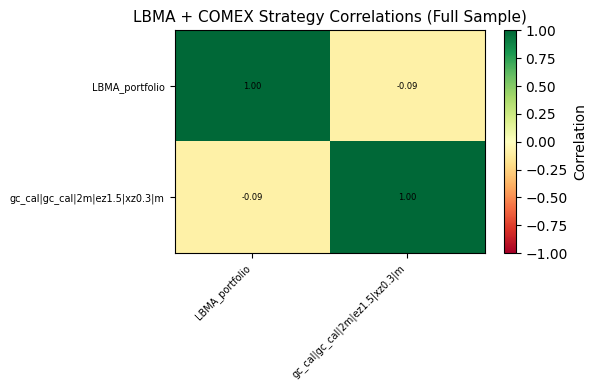

In [9]:
print('Section 6: Building combined LBMA + COMEX portfolio...')

import os

# Try to load LBMA portfolio P&L from saved outputs
LBMA_PNL_FILE = 'outputs/06_portfolio_pnl.csv'
lbma_pnl_df = None

if os.path.exists(LBMA_PNL_FILE):
    _tmp = pd.read_csv(LBMA_PNL_FILE)
    # detect date column
    date_col = [c for c in _tmp.columns if 'date' in c.lower()][0]
    _tmp[date_col] = pd.to_datetime(_tmp[date_col])
    _tmp = _tmp.set_index(date_col)
    # might be single-column (portfolio P&L) — we need per-strategy
    lbma_portfolio_pnl_series = _tmp.iloc[:,0] if _tmp.shape[1] == 1 else _tmp.mean(axis=1)
    print(f"Loaded LBMA portfolio P&L from {LBMA_PNL_FILE}: "
          f"{len(lbma_portfolio_pnl_series)} rows")
else:
    print(f"WARNING: {LBMA_PNL_FILE} not found. Cannot build combined portfolio.")
    lbma_portfolio_pnl_series = None

# Load LBMA strategy-level correlations if available
LBMA_CORR_FILE = 'outputs/05_strategy_correlations.csv'
lbma_strat_pnl = None
if os.path.exists(LBMA_CORR_FILE):
    lbma_corr = pd.read_csv(LBMA_CORR_FILE, index_col=0)
    # The correlation file doesn't have per-strategy P&L
    # We'll use LBMA portfolio as a single block vs COMEX strategies
    print(f"Loaded LBMA correlation matrix: {lbma_corr.shape}")

# ── Combined portfolio ─────────────────────────────────────────────────────
def portfolio_metrics_full(pnl, label):
    if len(pnl) == 0 or pnl.std() == 0:
        return {'sharpe': np.nan, 'maxdd': np.nan, 'calmar': np.nan,
                'ann_ret': np.nan, 'p_loss': np.nan}
    cum   = pnl.cumsum()
    dd    = cum - cum.cummax()
    ar    = pnl.mean() * 252
    av    = pnl.std()  * np.sqrt(252)
    sr    = ar / av
    md    = dd.min()
    cal   = ar / abs(md) if md != 0 else np.nan
    # P(annual loss) — approximate from daily distribution
    ann_pnl_sim = [pnl.sample(252, replace=True).sum() for _ in range(1000)]
    p_loss = np.mean(np.array(ann_pnl_sim) < 0) * 100
    return {'sharpe': sr, 'maxdd': md, 'calmar': cal,
            'ann_ret': ar, 'p_loss': p_loss}

results_table = []

# LBMA-only OOS
if lbma_portfolio_pnl_series is not None:
    lbma_oos = lbma_portfolio_pnl_series.loc[
        lbma_portfolio_pnl_series.index >= OOS_START]
    m_lbma = portfolio_metrics_full(lbma_oos, "LBMA only")
    results_table.append({'portfolio': 'LBMA only', **m_lbma})

# COMEX-only OOS
if len(comex_portfolio_pnl) > 0:
    comex_oos = comex_portfolio_pnl.loc[OOS_START:OOS_END]
    m_comex = portfolio_metrics_full(comex_oos, "COMEX only")
    results_table.append({'portfolio': 'COMEX only', **m_comex})

# Combined: LBMA series + COMEX filtered strategies
if lbma_portfolio_pnl_series is not None and len(comex_pnl_filtered) > 0:
    # Align indices
    common_idx = lbma_portfolio_pnl_series.index.intersection(comex_pnl_filtered.index)

    # Build combined pnl matrix: LBMA as single column + COMEX per-strategy
    lbma_col = lbma_portfolio_pnl_series.loc[common_idx].rename('lbma_portfolio')
    combined_mat = pd.concat([lbma_col, comex_pnl_filtered.loc[common_idx]], axis=1).fillna(0)

    # Correlation filter on combined (keep LBMA anchor, then add COMEX if low corr)
    corr_combined = combined_mat.corr()
    combined_keep = ['lbma_portfolio']   # always keep LBMA
    for col in comex_keep:
        if col in corr_combined.columns:
            max_c = corr_combined.loc[col, combined_keep].abs().max()
            if max_c < CORR_THRESHOLD:
                combined_keep.append(col)

    print(f"Combined portfolio: {len(combined_keep)} strategies "
          f"({len(combined_keep)-1} COMEX + 1 LBMA block)")

    comb_mat_filt = combined_mat[combined_keep]
    # Risk-parity weights
    comb_portfolio = pd.Series(0.0, index=comb_mat_filt.index)
    rebal_dates_c  = pd.date_range(
        comb_mat_filt.index[0], comb_mat_filt.index[-1], freq=REBAL_FREQ)
    comb_w = None
    for date in comb_mat_filt.index:
        if comb_w is None or date in rebal_dates_c:
            hist = comb_mat_filt.loc[:date].tail(RISK_PARITY_WINDOW)
            vols = hist.std().replace(0, np.nan)
            comb_w = (1/vols) / (1/vols).sum()
        comb_portfolio.loc[date] = (comb_mat_filt.loc[date] * comb_w).sum()

    comb_oos = comb_portfolio.loc[OOS_START:OOS_END]
    m_comb   = portfolio_metrics_full(comb_oos, "Combined")
    results_table.append({'portfolio': 'Combined', **m_comb})

    # Diversification gain
    if results_table:
        lbma_sr   = next((r['sharpe'] for r in results_table if r['portfolio']=='LBMA only'), np.nan)
        comex_sr  = next((r['sharpe'] for r in results_table if r['portfolio']=='COMEX only'), np.nan)
        comb_sr   = m_comb['sharpe']
        print(f"\nDiversification gain: max(LBMA,COMEX)={max(lbma_sr,comex_sr):.2f}  "
              f"→  Combined={comb_sr:.2f}  "
              f"({'IMPROVED' if comb_sr > max(lbma_sr, comex_sr) else 'NO GAIN'})")

    if SAVE_OUTPUTS:
        comb_portfolio.reset_index().rename(
            columns={0:'pnl_bp','index':'date'}).to_csv(
            f'{OUTPUT_DIR}06_combined_portfolio.csv', index=False)

# Print summary table
print()
print(f"{'Portfolio':<16}  {'OOS SR':>7}  {'Ann P&L':>9}  {'MaxDD':>9}  {'Calmar':>7}  {'P(loss)':>8}")
print('─'*70)
for r in results_table:
    print(f"  {r['portfolio']:<14}  "
          f"{r.get('sharpe',np.nan):>7.2f}  "
          f"{r.get('ann_ret',np.nan):>9.4f}  "
          f"{r.get('maxdd',np.nan):>9.4f}  "
          f"{r.get('calmar',np.nan):>7.2f}  "
          f"{r.get('p_loss',np.nan):>7.1f}%")

# ── Correlation heatmap ─────────────────────────────────────────────────────
if len(comex_pnl_filtered) > 0 and lbma_portfolio_pnl_series is not None:
    common = lbma_portfolio_pnl_series.index.intersection(comex_pnl_filtered.index)
    heat_df = pd.concat([
        lbma_portfolio_pnl_series.loc[common].rename('LBMA_portfolio'),
        comex_pnl_filtered.loc[common, comex_keep]
    ], axis=1).fillna(0)

    fig, ax = plt.subplots(figsize=(max(6, len(heat_df.columns)), max(4, len(heat_df.columns)//2)))
    corr_h = heat_df.corr()
    im = ax.imshow(corr_h.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(corr_h.columns)))
    ax.set_yticks(range(len(corr_h.columns)))
    labs = [c[:30] for c in corr_h.columns]
    ax.set_xticklabels(labs, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(labs, fontsize=7)
    for i in range(len(corr_h)):
        for j in range(len(corr_h.columns)):
            ax.text(j, i, f'{corr_h.iloc[i,j]:.2f}', ha='center', va='center', fontsize=6)
    plt.colorbar(im, ax=ax, label='Correlation')
    ax.set_title('LBMA + COMEX Strategy Correlations (Full Sample)', fontsize=11)
    plt.tight_layout()
    if SAVE_OUTPUTS:
        plt.savefig(f'{OUTPUT_DIR}06_correlation_heatmap.png', dpi=120, bbox_inches='tight')
    plt.show()


# 7. Attribution & Regime Analysis

Section 7: Attribution and regime analysis...

P&L attribution by block (OOS):
       oos_total_bp
block              
A_cal     20.361096


Trade statistics per strategy (OOS):
Strategy                                                 Trades    Hit%      AvgW      AvgL      PF
───────────────────────────────────────────────────────────────────────────────────────────────
  gc_cal|gc_cal|2m|ez1.5|xz0.3|mh20|cb0.08                   22   72.7%     1.629    -0.951    4.57


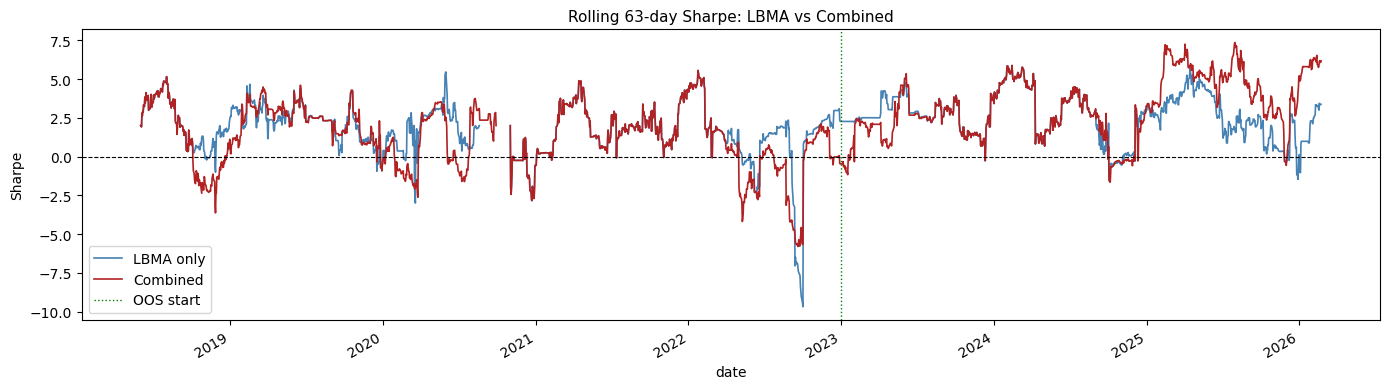


Worst 10 LBMA days (OOS) — COMEX P&L on same day:
  Date            LBMA P&L    COMEX P&L  Hedge?
  ──────────────────────────────────────────────────
  2024-10-03       -1.0497       0.0073  YES ✓
  2025-10-08       -0.6577       0.0000  NO
  2023-10-11       -0.3713       0.0000  NO
  2023-10-23       -0.3167       0.0000  NO
  2025-08-22       -0.3071      -0.2833  NO
  2025-10-02       -0.3035       0.0000  NO
  2025-03-05       -0.3007       0.0000  NO
  2025-02-17       -0.2901       0.0000  NO
  2025-04-23       -0.2589       0.0000  NO
  2025-08-13       -0.2466       0.0000  NO


In [10]:
print('Section 7: Attribution and regime analysis...')

if len(comex_keep) == 0:
    print("No COMEX strategies — skipping attribution.")
else:
    # ── 7.1  P&L by block ────────────────────────────────────────────────
    block_map = {
        'gc_comex_carry_2m':      'A_cal',
        'gc_comex_carry_4m':      'A_cal',
        'si_comex_carry_2m':      'A_cal',
        'gc_cal_curvature':       'A_cal',
        'gc_si_cal_ratio':        'A_cal',
        'gc_comex_lbma_basis':    'B_basis',
        'si_comex_lbma_basis':    'B_basis',
        'gc_si_comex_basis_spread':'B_basis',
        'efp_xau_bp':             'C_efp',
        'efp_xag_bp':             'C_efp',
        'efp_xau_xag_diff':       'C_efp',
        'gc_comex_curve_slope':   'D_slope',
        'comex_lbma_slope_basis': 'D_slope',
    }

    attrib_rows = []
    for key in comex_keep:
        parts = key.split('|')
        feat_col = None
        for col in comex_features:
            test_key = (f"{FTYPE_MAP.get(col,('unk','unk','unk'))[1]}|"
                        f"{FTYPE_MAP.get(col,('unk','unk','unk'))[0]}|"
                        f"{FTYPE_MAP.get(col,('unk','unk','unk'))[2]}")
            if parts[0] == FTYPE_MAP.get(col,('unk','unk','unk'))[1] and                parts[1] == FTYPE_MAP.get(col,('unk','unk','unk'))[0]:
                feat_col = col; break
        if feat_col is None:
            # fallback: match by bucket
            for col in comex_features:
                if FTYPE_MAP.get(col,('','',''))[2] == parts[2]:
                    feat_col = col; break
        if feat_col is None: continue

        daily_pnl = comex_candidate_daily.get(key)
        if daily_pnl is None: continue

        oos_pnl = daily_pnl.loc[OOS_START:OOS_END]
        block   = block_map.get(feat_col, 'other')
        attrib_rows.append({
            'key': key, 'feature': feat_col, 'block': block,
            'oos_total_bp': oos_pnl.sum(),
            'oos_sharpe':   oos_pnl.mean()*252/(oos_pnl.std()*np.sqrt(252))
                            if oos_pnl.std() > 0 else np.nan,
            'oos_trades':   int((oos_pnl != 0).sum() // 20),  # rough estimate
        })

    if attrib_rows:
        attrib_df = pd.DataFrame(attrib_rows)
        print("\nP&L attribution by block (OOS):")
        print(attrib_df.groupby('block')[['oos_total_bp']].sum().to_string())
        if SAVE_OUTPUTS:
            attrib_df.to_csv(f'{OUTPUT_DIR}07_attribution.csv', index=False)

    # ── 7.2  Trade-level statistics ───────────────────────────────────────
    print("\n\nTrade statistics per strategy (OOS):")
    print(f"{'Strategy':<55}  {'Trades':>6}  {'Hit%':>6}  {'AvgW':>8}  {'AvgL':>8}  {'PF':>6}")
    print('─' * 95)
    for key in comex_keep:
        row_match = comex_selected[comex_selected.apply(
            lambda r: (f"{r['metal']}|{r['feature_type']}|{r['bucket']}|"
                       f"ez{r['entry_z']}|xz{r['exit_z']}|"
                       f"mh{int(r['max_hold'])}|cb{r['cost_bp']}") == key, axis=1)]
        if not len(row_match): continue
        row = row_match.iloc[0]
        r = backtest_single(df.loc[OOS_START:OOS_END], row['signal_col'],
                            row['feature_col'], entry_z=row['entry_z'],
                            exit_z=row['exit_z'], stop_z=STOP_Z,
                            max_hold=int(row['max_hold']), cost_bp=row['cost_bp'])
        tl = r['trade_log']
        if len(tl) == 0: continue
        wins  = tl[tl['pnl_bp'] > 0]['pnl_bp']
        losses= tl[tl['pnl_bp'] <= 0]['pnl_bp']
        hit   = len(wins) / len(tl) * 100
        aw    = wins.mean()  if len(wins)   else 0
        al    = losses.mean()if len(losses) else 0
        pf    = abs(aw*len(wins)) / abs(al*len(losses)) if len(losses) and al != 0 else np.nan
        print(f"  {key[:53]:<53}  {len(tl):>6d}  {hit:>5.1f}%  "
              f"{aw:>8.3f}  {al:>8.3f}  {pf:>6.2f}")

    # ── 7.3  Rolling Sharpe: LBMA vs Combined ─────────────────────────────
    if lbma_portfolio_pnl_series is not None and 'comb_portfolio' in dir():
        fig, ax = plt.subplots(figsize=(14, 4))
        roll_sr_lbma = (lbma_portfolio_pnl_series.rolling(63).mean() * 252 /
                        (lbma_portfolio_pnl_series.rolling(63).std() * np.sqrt(252)))
        roll_sr_comb = (comb_portfolio.rolling(63).mean() * 252 /
                        (comb_portfolio.rolling(63).std() * np.sqrt(252)))
        roll_sr_lbma.plot(ax=ax, label='LBMA only', lw=1.2, color='steelblue')
        roll_sr_comb.plot(ax=ax, label='Combined',  lw=1.2, color='firebrick')
        ax.axhline(0, color='black', lw=0.8, ls='--')
        ax.axvline(pd.Timestamp(OOS_START), color='green', lw=1, ls=':', label='OOS start')
        ax.set_title('Rolling 63-day Sharpe: LBMA vs Combined', fontsize=11)
        ax.legend(); ax.set_ylabel('Sharpe')
        plt.tight_layout()
        if SAVE_OUTPUTS:
            plt.savefig(f'{OUTPUT_DIR}07_rolling_sharpe.png', dpi=120, bbox_inches='tight')
        plt.show()

    # ── 7.4  Worst LBMA days — did COMEX hedge? ───────────────────────────
    if lbma_portfolio_pnl_series is not None and len(comex_portfolio_pnl) > 0:
        common_oos = lbma_portfolio_pnl_series.loc[OOS_START:].index.intersection(
            comex_portfolio_pnl.loc[OOS_START:].index)
        worst10 = lbma_portfolio_pnl_series.loc[common_oos].nsmallest(10)
        print("\nWorst 10 LBMA days (OOS) — COMEX P&L on same day:")
        print(f"  {'Date':<12}  {'LBMA P&L':>10}  {'COMEX P&L':>11}  {'Hedge?'}")
        print('  ' + '─'*50)
        for dt, lv in worst10.items():
            cv = comex_portfolio_pnl.get(dt, np.nan) if dt in comex_portfolio_pnl.index else np.nan
            hedge = 'YES ✓' if (not np.isnan(cv) and cv > 0) else ('NO' if not np.isnan(cv) else '-')
            print(f"  {str(dt.date()):<12}  {lv:>10.4f}  {cv:>11.4f}  {hedge}")


# 8. Daily Signal Integration

Blotter-compatible with `silver_gold_lease_curve_v2.ipynb` Section 10c.

In [11]:
print('Section 8: Daily signal integration (blotter-compatible)...')

TENOR_DAYS_MAP = {'1m': 30, '3m': 91, '6m': 182, '9m': 273, '1y': 365, '2y': 730}
CURRENT_SPOT_XAU = df['xauusd_spot'].iloc[-1] if 'xauusd_spot' in df.columns else 2900.0
CURRENT_SPOT_XAG = df['xagusd_spot'].iloc[-1] if 'xagusd_spot' in df.columns else 30.0

def comex_map_to_instrument(feature_col, state, oz=1.0, spot=2900.0):
    """Map COMEX feature to blotter instrument description."""
    contracts = max(1, round(oz / 100))  # 1 GC contract = 100 oz

    if feature_col in ('gc_comex_carry_2m',):
        instrument = 'COMEX GC Calendar Spread \u2014 Front/Second'
        if state == 1:
            leg1 = f'BUY  GC front (go long nearby, +{contracts} contracts)'
            leg2 = f'SELL GC second (short deferred, -{contracts} contracts)'
            desc = 'Long GC calendar spread: buy nearby / sell deferred'
        else:
            leg1 = f'SELL GC front (short nearby, -{contracts} contracts)'
            leg2 = f'BUY  GC second (long deferred, +{contracts} contracts)'
            desc = 'Short GC calendar spread: sell nearby / buy deferred'
        dv01 = oz * spot * (GC_DAYS_12 / 360) * 0.0001
        return {'instrument': instrument, 'leg1': leg1, 'leg2': leg2, 'leg3': '-',
                'direction_desc': desc, 'contracts': contracts,
                'dv01_gross': dv01, 'dv01_net': 0.0,
                'note': 'CME electronic execution; tight bid/ask on calendar spread'}

    elif feature_col == 'gc_comex_carry_4m':
        instrument = 'COMEX GC Calendar Spread \u2014 Front/Third'
        if state == 1:
            leg1 = f'BUY  GC front (+{contracts} contracts)'
            leg2 = f'SELL GC third (-{contracts} contracts)'
            desc = 'Long GC 1/3 calendar: buy front / sell 3rd contract'
        else:
            leg1 = f'SELL GC front (-{contracts} contracts)'
            leg2 = f'BUY  GC third (+{contracts} contracts)'
            desc = 'Short GC 1/3 calendar: sell front / buy 3rd contract'
        dv01 = oz * spot * (GC_DAYS_13 / 360) * 0.0001
        return {'instrument': instrument, 'leg1': leg1, 'leg2': leg2, 'leg3': '-',
                'direction_desc': desc, 'contracts': contracts,
                'dv01_gross': dv01, 'dv01_net': 0.0,
                'note': 'CME electronic execution; wider spread than 1/2 calendar'}

    elif feature_col == 'si_comex_carry_2m':
        instrument = 'COMEX SI Calendar Spread \u2014 Front/Second'
        if state == 1:
            leg1 = f'BUY  SI front (+{contracts * 50} contracts @5000oz ea)'
            leg2 = f'SELL SI second (-{contracts * 50} contracts)'
            desc = 'Long SI calendar spread'
        else:
            leg1 = f'SELL SI front'
            leg2 = f'BUY  SI second'
            desc = 'Short SI calendar spread'
        dv01 = oz * CURRENT_SPOT_XAG * (SI_DAYS_12 / 360) * 0.0001
        return {'instrument': instrument, 'leg1': leg1, 'leg2': leg2, 'leg3': '-',
                'direction_desc': desc, 'contracts': contracts,
                'dv01_gross': dv01, 'dv01_net': 0.0,
                'note': '1 SI contract = 5,000 troy oz; adjust contract count accordingly'}

    elif feature_col in ('gc_comex_lbma_basis', 'si_comex_lbma_basis',
                          'gc_si_comex_basis_spread', 'comex_lbma_slope_basis'):
        metal = 'GC/XAU' if 'gc' in feature_col or 'xau' in feature_col else 'SI/XAG'
        instrument = f'{metal} COMEX/LBMA Carry Basis'
        if state == 1:
            leg1 = f'BUY  {metal.split("/")[0]} calendar spread (COMEX futures)'
            leg2 = f'PAY  fixed {metal.split("/")[1]} swap 2m (LBMA OTC)'
            desc = f'Long {metal} COMEX/LBMA basis: COMEX cheap vs LBMA'
        else:
            leg1 = f'SELL {metal.split("/")[0]} calendar spread (COMEX futures)'
            leg2 = f'RECEIVE fixed {metal.split("/")[1]} swap 2m (LBMA OTC)'
            desc = f'Short {metal} COMEX/LBMA basis: COMEX rich vs LBMA'
        dv01 = oz * spot * (61 / 360) * 0.0001
        return {'instrument': instrument, 'leg1': leg1, 'leg2': leg2, 'leg3': '-',
                'direction_desc': desc, 'contracts': contracts,
                'dv01_gross': dv01, 'dv01_net': 0.0,
                'note': '*** CROSS-VENUE: requires simultaneous COMEX futures + LBMA OTC swap execution. Alert dealer before entry.'}

    elif feature_col in ('efp_xau_bp', 'efp_xau_xag_diff'):
        instrument = 'XAU Exchange for Physical (EFP)'
        if state == 1:
            leg1 = f'SELL GC front (futures, -{contracts} contracts)'
            leg2 = f'BUY  XAU spot (physical, +{oz:,.0f} oz)'
            desc = 'Long EFP: sell futures / buy spot (futures rich vs spot)'
        else:
            leg1 = f'BUY  GC front (futures, +{contracts} contracts)'
            leg2 = f'SELL XAU spot (physical, -{oz:,.0f} oz)'
            desc = 'Short EFP: buy futures / sell spot (futures cheap vs spot)'
        dv01 = oz * spot * (EFP_DAYS / 360) * 0.0001
        return {'instrument': instrument, 'leg1': leg1, 'leg2': leg2, 'leg3': '-',
                'direction_desc': desc, 'contracts': contracts,
                'dv01_gross': dv01, 'dv01_net': 0.0,
                'note': '*** EFP: execute via LBMA member dealer. Must notify CME within 15 min of execution.'}

    elif feature_col == 'efp_xag_bp':
        instrument = 'XAG Exchange for Physical (EFP)'
        if state == 1:
            leg1 = 'SELL SI front (futures)'
            leg2 = 'BUY  XAG spot (physical)'
            desc = 'Long XAG EFP: sell futures / buy spot'
        else:
            leg1 = 'BUY  SI front (futures)'
            leg2 = 'SELL XAG spot (physical)'
            desc = 'Short XAG EFP: buy futures / sell spot'
        dv01 = oz * CURRENT_SPOT_XAG * (EFP_DAYS / 360) * 0.0001
        return {'instrument': instrument, 'leg1': leg1, 'leg2': leg2, 'leg3': '-',
                'direction_desc': desc, 'contracts': contracts,
                'dv01_gross': dv01, 'dv01_net': 0.0,
                'note': '*** EFP: execute via LBMA member dealer. Must notify CME within 15 min.'}

    else:  # generic
        return {'instrument': feature_col, 'leg1': '-', 'leg2': '-', 'leg3': '-',
                'direction_desc': '-', 'contracts': 1, 'dv01_gross': 0, 'dv01_net': 0,
                'note': ''}


# ── Build today's blotter ────────────────────────────────────────────────
today      = df.index[-1]
blotter_rows = []

for col in comex_features:
    zcol = f'z_{col}'
    if zcol not in df.columns: continue

    z_today = df[zcol].iloc[-1]
    z_prev  = df[zcol].iloc[-2] if len(df) > 1 else np.nan
    f_today = df[col].iloc[-1]
    f_mean  = df[col].rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).mean().iloc[-1]

    ez = 1.5  # default entry threshold (best param from sweep if available)
    if len(comex_keep) > 0:
        key_match = [k for k in comex_keep if col in k]
        if key_match:
            # extract entry_z from key string
            for seg in key_match[0].split('|'):
                if seg.startswith('ez'):
                    try: ez = float(seg[2:]); break
                    except: pass

    if abs(z_today) >= ez:
        signal    = 'ENTRY SIGNAL'
        direction = 'LONG' if z_today < 0 else 'SHORT'
    elif abs(z_today) >= ez * 0.80:
        signal    = 'APPROACHING'
        direction = 'LONG' if z_today < 0 else 'SHORT'
    else:
        signal    = 'watch'
        direction = '-'

    state = -1 if direction == 'SHORT' else (1 if direction == 'LONG' else 0)
    instr = comex_map_to_instrument(col, state, oz=100, spot=CURRENT_SPOT_XAU)

    blotter_rows.append({
        'date': today.date(), 'feature': col, 'z_score': round(z_today, 3),
        'z_1d_chg': round(z_today - z_prev, 3) if not np.isnan(z_prev) else np.nan,
        'raw_value': round(f_today, 4), 'mean_252d': round(f_mean, 4),
        'direction': direction, 'signal': signal, 'entry_z': ez,
        'instrument': instr['instrument'], 'description': instr['direction_desc'],
        'leg1': instr['leg1'], 'leg2': instr['leg2'],
        'contracts': instr.get('contracts', 1),
        'dv01_gross': round(instr.get('dv01_gross', 0), 2),
        'note': instr.get('note', ''),
    })

blotter_df = pd.DataFrame(blotter_rows)

# Print blotter
print(f"\n{'='*78}")
print(f"  COMEX SIGNAL BLOTTER  --  {today.date()}")
print(f"  XAU spot: ${CURRENT_SPOT_XAU:,.0f}  |  XAG spot: ${CURRENT_SPOT_XAG:.2f}")
print(f"{'='*78}")

active   = blotter_df[blotter_df['signal'] == 'ENTRY SIGNAL']
watching = blotter_df[blotter_df['signal'] == 'APPROACHING']
quiet    = blotter_df[blotter_df['signal'] == 'watch']

if len(active) > 0:
    print(f"\n*** ACTIVE SIGNALS ({len(active)}) ***")
    for _, r in active.iterrows():
        print(f"\n  [ENTRY] {r['feature']:<32}  z={r['z_score']:+.3f}  dz={r['z_1d_chg']:+.3f}")
        print(f"  {'─'*65}")
        print(f"  Instrument : {r['instrument']}")
        print(f"  Direction  : {r['description']}")
        print(f"  Leg 1 \u2192 {r['leg1']}")
        print(f"  Leg 2 \u2192 {r['leg2']}")
        print(f"  Raw value  : {r['raw_value']:.4f}%  |  252d mean: {r['mean_252d']:.4f}%")
        print(f"  DV01       : ${r['dv01_gross']:,.2f} (per 1bp, {r['contracts']} contracts)")
        if r['note']:
            print(f"  NOTE       : {r['note']}")
else:
    print("\n  No active entry signals.")

if len(watching) > 0:
    print(f"\n--- APPROACHING ({len(watching)}) ---")
    for _, r in watching.iterrows():
        print(f"  [WATCH]  {r['feature']:<32}  z={r['z_score']:+.3f}  "
              f"({r['direction']})  raw={r['raw_value']:.4f}%")

print(f"\n--- MONITORING ({len(quiet)}) ---")
for _, r in quiet.iterrows():
    print(f"  {r['feature']:<32}  z={r['z_score']:+.3f}  signal={r['signal']}")

print(f"\n{'='*78}")

if SAVE_OUTPUTS:
    blotter_df.to_csv(f'{OUTPUT_DIR}08_daily_blotter.csv', index=False)
    print(f"Saved: {OUTPUT_DIR}08_daily_blotter.csv")


Section 8: Daily signal integration (blotter-compatible)...

  COMEX SIGNAL BLOTTER  --  2026-02-22
  XAU spot: $5,107  |  XAG spot: $84.65

  No active entry signals.

--- APPROACHING (1) ---
  [WATCH]  si_comex_carry_2m                 z=-1.303  (LONG)  raw=4.5225%

--- MONITORING (12) ---
  gc_comex_carry_2m                 z=-1.133  signal=watch
  gc_comex_carry_4m                 z=-1.129  signal=watch
  gc_cal_curvature                  z=+0.514  signal=watch
  gc_si_cal_ratio                   z=+1.037  signal=watch
  gc_comex_lbma_basis               z=+0.166  signal=watch
  si_comex_lbma_basis               z=-1.043  signal=watch
  gc_si_comex_basis_spread          z=+1.086  signal=watch
  efp_xau_bp                        z=+nan  signal=watch
  efp_xag_bp                        z=+nan  signal=watch
  efp_xau_xag_diff                  z=+nan  signal=watch
  gc_comex_curve_slope              z=+0.514  signal=watch
  comex_lbma_slope_basis            z=+0.457  signal=watch

Save

# 9. Bloomberg Data Pull Spec

BQL queries for production COMEX data feed.

In [12]:
print('Section 9: Bloomberg COMEX data pull specification')
print()

GC_FUTURES_FIELDS = {
    'gc_fut_front':  'GC1 COMDTY PX_LAST',
    'gc_fut_second': 'GC2 COMDTY PX_LAST',
    'gc_fut_third':  'GC3 COMDTY PX_LAST',
    'gc_expiry_1':   'GC1 COMDTY LAST_TRADEABLE_DT',   # for exact DTE
    'gc_expiry_2':   'GC2 COMDTY LAST_TRADEABLE_DT',
    'gc_expiry_3':   'GC3 COMDTY LAST_TRADEABLE_DT',
}
SI_FUTURES_FIELDS = {
    'si_fut_front':  'SI1 COMDTY PX_LAST',
    'si_fut_second': 'SI2 COMDTY PX_LAST',
    'si_fut_third':  'SI3 COMDTY PX_LAST',
    'si_expiry_1':   'SI1 COMDTY LAST_TRADEABLE_DT',
    'si_expiry_2':   'SI2 COMDTY LAST_TRADEABLE_DT',
}
EFP_SPOT_FIELDS = {
    'xauusd_spot':   'XAU CURNCY PX_LAST',
    'xagusd_spot':   'XAG CURNCY PX_LAST',
    'lbma_gold_am':  'GOLDLNAM INDEX PX_LAST',
    'lbma_gold_pm':  'GOLDLNPM INDEX PX_LAST',
}

print("# ─── Required Bloomberg fields for COMEX expansion ───────────────────")
print("# Pull daily using BQL or Bloomberg API (supplement to LBMA notebook pull)")
print()
print("GC_FUTURES_FIELDS =", GC_FUTURES_FIELDS)
print()
print("SI_FUTURES_FIELDS =", SI_FUTURES_FIELDS)
print()
print("EFP_SPOT_FIELDS =",   EFP_SPOT_FIELDS)
print()
print("# NOTE: gc_expiry_1/2/3 allow computation of EXACT days-to-expiry")
print("# for DV01 and annualised carry, replacing the 61-day approximation.")
print("# Update GC_CALENDAR_DAYS dynamically from expiry dates in production:")
print("#")
print("#   from datetime import date")
print("#   gc_days_12 = (gc_expiry_2 - gc_expiry_1).days")
print("#   gc_days_13 = (gc_expiry_3 - gc_expiry_1).days")
print("#   CONFIG['GC_CALENDAR_DAYS'] = {'1_2': gc_days_12, '1_3': gc_days_13}")
print()
print("# ─── BQL template (BQNT) ────────────────────────────────────────────")
print('''
# import bql
# bq = bql.Service()
# universe = bq.univ.list(['GC1 COMDTY','GC2 COMDTY','GC3 COMDTY',
#                           'SI1 COMDTY','SI2 COMDTY',
#                           'XAU CURNCY','XAG CURNCY',
#                           'GOLDLNAM INDEX','GOLDLNPM INDEX'])
# item = bq.data.px_last(dates=bq.func.range(start_date, end_date),
#                         frq='D', fill='prev')
# response = bq.execute(bql.Request(universe, item))
# df_bbg = response[0].df().pivot(columns='ID', values='PX_LAST')
# rename columns to match DATA_FILE column names above
''')
print("Section 9 complete.")


Section 9: Bloomberg COMEX data pull specification

# ─── Required Bloomberg fields for COMEX expansion ───────────────────
# Pull daily using BQL or Bloomberg API (supplement to LBMA notebook pull)

GC_FUTURES_FIELDS = {'gc_fut_front': 'GC1 COMDTY PX_LAST', 'gc_fut_second': 'GC2 COMDTY PX_LAST', 'gc_fut_third': 'GC3 COMDTY PX_LAST', 'gc_expiry_1': 'GC1 COMDTY LAST_TRADEABLE_DT', 'gc_expiry_2': 'GC2 COMDTY LAST_TRADEABLE_DT', 'gc_expiry_3': 'GC3 COMDTY LAST_TRADEABLE_DT'}

SI_FUTURES_FIELDS = {'si_fut_front': 'SI1 COMDTY PX_LAST', 'si_fut_second': 'SI2 COMDTY PX_LAST', 'si_fut_third': 'SI3 COMDTY PX_LAST', 'si_expiry_1': 'SI1 COMDTY LAST_TRADEABLE_DT', 'si_expiry_2': 'SI2 COMDTY LAST_TRADEABLE_DT'}

EFP_SPOT_FIELDS = {'xauusd_spot': 'XAU CURNCY PX_LAST', 'xagusd_spot': 'XAG CURNCY PX_LAST', 'lbma_gold_am': 'GOLDLNAM INDEX PX_LAST', 'lbma_gold_pm': 'GOLDLNPM INDEX PX_LAST'}

# NOTE: gc_expiry_1/2/3 allow computation of EXACT days-to-expiry
# for DV01 and annualised carry, replacing the 